In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        pass
        #print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
#/kaggle/input/datasets/divyansh22/dummy-astronomy-data/Cutout Files/

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import itertools

In [3]:
transform = transforms.Compose([
    transforms.Resize([64, 64]),
    transforms.Grayscale(1),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5], std = [0.5])
])

In [4]:
dataset = datasets.ImageFolder('/kaggle/input/datasets/divyansh22/dummy-astronomy-data/Cutout Files', transform = transform)
train_sz = int(len(dataset) * 0.8)
train_dataset, val_dataset = random_split(dataset, [train_sz, len(dataset) - train_sz])

In [5]:
print(dataset.class_to_idx)
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')

{'galaxy': 0, 'star': 1}
Train: 3188, Val: 798


In [6]:
train_loader = DataLoader(train_dataset, batch_size = 1024, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 1024, shuffle = True)

In [7]:
def visualize(image):

    def denormalize(im):
        return im * 0.5 + 0.5
    
    im = denormalize(image[0]).permute(1, 2, 0)
    cl = image[1]
    plt.imshow(im.numpy(), cmap = 'inferno')
    plt.title(dataset.classes[cl])
    plt.axis('off')

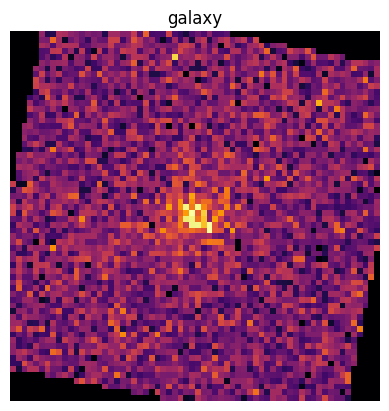

In [8]:
visualize(dataset[0])

In [9]:
batch_size = 1024
channel_num = 1
image_height = 64
image_width = 64
patch_size = 8
embed_size = 64
blocks_num = 4
classes_num = 1 # binary classification
hidden_layer = 128
num_head = 4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [10]:
class FeedForward(nn.Module):

    def __init__(self, embed_size):
        super().__init__()
        self.linear1 = nn.Linear(embed_size, embed_size * 4)
        self.act = nn.SiLU()
        self.linear2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        x = self.act(self.linear1(x)) # (batch_size, num_patches, embed_size) -> (batch_size, num_patches, embed_size * 4)
        x = self.linear2(x) # (batch_size, num_patches, embed_size * 4) -> (batch_size, num_patches, embed_size)
        return x

class TransformerBlock(nn.Module):

    def __init__(self, embed_size, num_head):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_size)
        self.attn = nn.MultiheadAttention(embed_size, num_head, batch_first = True, dropout = 0.1) #added dropout
        self.norm2 = nn.LayerNorm(embed_size)
        self.ff = FeedForward(embed_size)
    
    def forward(self, x):
        norm_x = self.norm1(x) # (batch_size, num_patches, embed_size) -> (batch_size, num_patches, embed_size)
        attn_x = self.attn(key = norm_x, query = norm_x, value = norm_x)[0] 
        x = x + attn_x # (batch_size, num_patches, embed_size) -> (batch_size, num_patches, embed_size)
        x = self.ff(self.norm2(x)) + x # (batch_size, num_patches, embed_size) -> (batch_size, num_patches, embed_size)
        return x

class MLPClassificationHead(nn.Module):

    def __init__(self, embed_size, hidden_layer, classes_num):
        super().__init__()
        self.linear1 = nn.Linear(embed_size, hidden_layer)
        self.silu = nn.SiLU()
        self.dropout = nn.Dropout(0.2) #added dropout
        self.linear2  = nn.Linear(hidden_layer, classes_num)
    
    def forward(self, x):
        x = self.linear1(x) # (batch_size, embed_size) -> (batch_size, hidden_layer)
        x = self.linear2(self.dropout(self.silu(x))) # (batch_size, hidden_layer) -> (batch_size, classes_num)
        return x


class ViT(nn.Module):

    def __init__(self, batch_size, channel_num, image_height, image_width,  patch_size, embed_size, blocks_num, classes_num, hidden_layer, num_head):
        super().__init__()
        p_height = image_height // patch_size
        p_width = image_width // patch_size
        patches_num = p_height * p_width
        self.patches_num = patches_num
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.p_height = p_height
        self.p_width = p_width
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_size))
        self.pos_enc = nn.Embedding(patches_num + 1, embed_size)
        self.linear1 = nn.Linear(channel_num * patch_size * patch_size, embed_size)
        self.transformer_blocks = nn.Sequential(*[TransformerBlock(embed_size, num_head) for _ in range(blocks_num)])
        self.mlp_head = MLPClassificationHead(embed_size, hidden_layer, classes_num)
    
    def forward(self, x): # x - (batch_size, channels, height, width)
        B, C, H, W = x.shape
        x = x.reshape(B, C, self.p_height, self.patch_size, self.p_width, self.patch_size) 
        x = x.permute(0, 2, 4, 3, 5, 1)
        x = x.reshape(B, self.patches_num, (self.patch_size ** 2) * C)
        x = self.linear1(x) # (B, patches_num, patch_size ** 2 * C) -> (B, patches_num, embed_size)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim = 1)
        x = x + self.pos_enc(torch.arange(self.patches_num + 1).to(device)) # (B, patches_num, embed_size) + (patches_num, embed_size) -> (B, patches_num, embed_size)
        x = self.transformer_blocks(x)
        cls_out = x[:, 0] # (B, embed_size)
        logits = self.mlp_head(cls_out)
        if logits.shape[1] == 1:
            logits = logits.flatten(0, -1)
        return logits

In [11]:
model = ViT(batch_size, channel_num, image_height, image_width, patch_size, embed_size, blocks_num, classes_num, hidden_layer, num_head).to(device)
print(f'Total number of parameters: {sum(p.numel() for p in model.parameters())}')

Total number of parameters: 216769


In [12]:
n_galaxy = 942
n_star = 3044

In [13]:
@torch.no_grad()
def get_stats(loader, criterion, num_batches = 10):
    total_num = 0
    total_correct = 0
    total_loss = 0
    model.eval()
    for batch, labels in itertools.islice(loader, num_batches):
        batch = batch.to(device)
        labels = labels.float().to(device)
        logits = model(batch)
        loss = criterion(logits, labels)
        total_num += len(batch)
        total_loss += len(batch) * loss.item()
        total_correct += (torch.abs(torch.sigmoid(logits) - labels) < 0.5).sum().item()
    model.train()
    return total_loss / total_num, total_correct / total_num

In [14]:
EPOCHS = 300
optimizer = torch.optim.Adam(model.parameters(), lr = 5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = EPOCHS)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([n_galaxy / n_star]).to(device))
model.train()
stats_every = 10

train_accuracy = []
train_losses = []
val_accuracy = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    for batch, labels in train_loader:
        batch = batch.to(device)
        labels = labels.float().to(device)
        logits = model(batch)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    tr_loss, tr_acc = get_stats(train_loader, criterion, num_batches=len(train_loader))
    val_loss, val_acc = get_stats(val_loader, criterion, num_batches=len(val_loader))
    train_accuracy.append(tr_acc)
    train_losses.append(tr_loss)
    val_accuracy.append(val_acc)
    val_losses.append(val_loss)
    if epoch % stats_every == 0:
        print(f'Epoch {epoch}/{EPOCHS}:')
        print('-'*50)
        print(f'TRAIN: Loss {tr_loss}, Accuracy {tr_acc * 100}%')
        print(f'VAL: Loss {val_loss}, Accuracy {val_acc * 100}%')
        
    scheduler.step()

Epoch 10/300:
--------------------------------------------------
TRAIN: Loss 0.32704813081018597, Accuracy 23.996235884567128%
VAL: Loss 0.3288203179836273, Accuracy 24.686716791979947%
Epoch 20/300:
--------------------------------------------------
TRAIN: Loss 0.32019986389870925, Accuracy 45.95357590966123%
VAL: Loss 0.32167062163352966, Accuracy 48.1203007518797%
Epoch 30/300:
--------------------------------------------------
TRAIN: Loss 0.29749006141383794, Accuracy 64.46047678795483%
VAL: Loss 0.29532670974731445, Accuracy 64.41102756892231%
Epoch 40/300:
--------------------------------------------------
TRAIN: Loss 0.28027315129300434, Accuracy 79.89335006273525%
VAL: Loss 0.2803341746330261, Accuracy 79.19799498746866%
Epoch 60/300:
--------------------------------------------------
TRAIN: Loss 0.2294861647011794, Accuracy 82.05771643663739%
VAL: Loss 0.21535979211330414, Accuracy 83.95989974937343%
Epoch 70/300:
--------------------------------------------------
TRAIN: Loss 

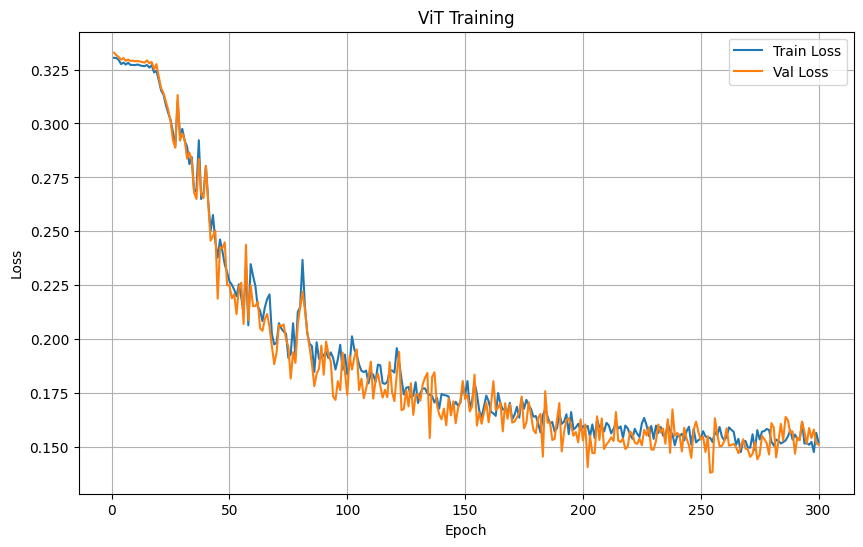

In [15]:
plt.figure(figsize = (10, 6))
plt.title('ViT Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(torch.arange(len(train_losses)) + 1, train_losses, label = 'Train Loss');
plt.plot(torch.arange(len(val_losses)) + 1, val_losses, label = 'Val Loss');
plt.grid()
plt.legend()
plt.show()

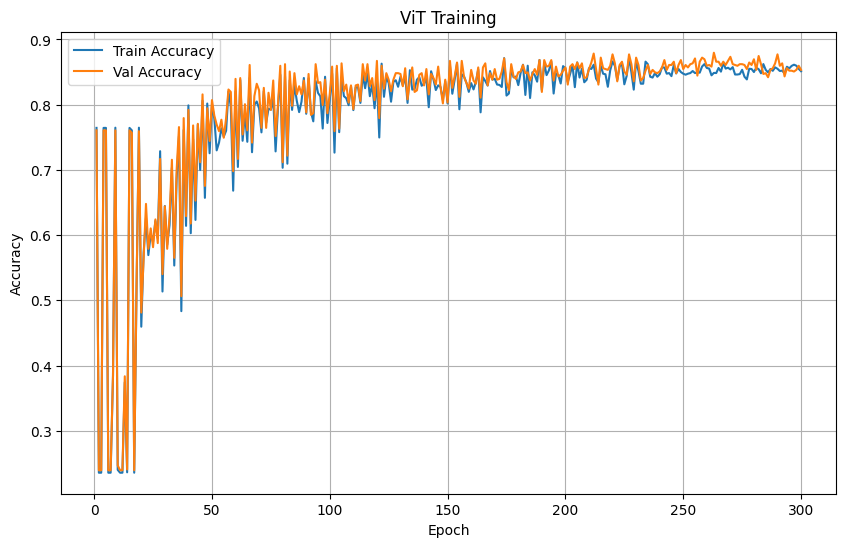

In [16]:
plt.figure(figsize = (10, 6))
plt.title('ViT Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(torch.arange(len(train_losses)) + 1, train_accuracy, label = 'Train Accuracy');
plt.plot(torch.arange(len(val_losses)) + 1, val_accuracy, label = 'Val Accuracy');
plt.grid()
plt.legend()
plt.show()

              precision    recall  f1-score   support

      galaxy       0.65      0.84      0.74       191
        star       0.95      0.86      0.90       607

    accuracy                           0.86       798
   macro avg       0.80      0.85      0.82       798
weighted avg       0.88      0.86      0.86       798



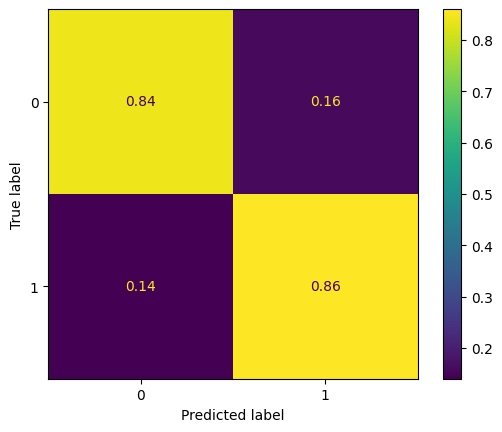

In [17]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_labels = []
all_logits = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()
        all_logits.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['galaxy', 'star']))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, normalize='true');

In [18]:
from sklearn.metrics import precision_recall_curve

probs = torch.sigmoid(torch.tensor(all_logits))
precisions, recalls, thresholds = precision_recall_curve(all_labels, probs, pos_label=0)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[f1_scores[:-1].argmax()]
print(f"Оптимальный порог: {best_threshold}")

Оптимальный порог: 0.5004381537437439
